# NB06 — Evaluation & Ablation Study
## EPGT Research Pipeline | Emoji Pragmatic Graph Transformer

---

### Tujuan Notebook

Notebook ini melakukan evaluasi komprehensif pada **test set** dan ablation study lengkap.

**Tahap 1 — Test Set Evaluation**
Load best checkpoint tiap model → evaluasi pada test set → classification report per task

**Tahap 2 — Ablation Study (5 konfigurasi)**
- ABL-1: No Graph (zero graph embedding)
- ABL-2: No Fusion (concat instead of cross-attention)
- ABL-3: No Emoji (≡ B1, IndoBERT text-only)
- ABL-4: No Position (zero p_i in node features)
- ABL-5: Full EPGT (reference)

**Tahap 3 — Visualisasi & Analisis**
- Comparison table (baseline vs EPGT)
- Ablation table
- Confusion matrices per task
- Attention weight visualization
- Error analysis

---

### Output
```
EPGT_Research/outputs/
├── tables/  evaluation_results.json, ablation_table.json
└── figures/ confusion_matrices.png, ablation_bar.png,
             attention_viz.png, error_analysis.png
```

**Blueprint Reference:** Section 5.1 Evaluation Protocol, Section 5.2 Ablation Study

---
## BAGIAN 1 — ENVIRONMENT SETUP

In [1]:
# ============================================================
# CELL 1.1 — Install & Mount
# ============================================================

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torch-geometric transformers emoji pandas numpy tqdm scikit-learn matplotlib seaborn

from google.colab import drive
import sys, torch
from pathlib import Path

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/EPGT_Research")
SRC_PATH   = str(DRIVE_ROOT / "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 43.8 MB/s eta 0:00:00
Mounted at /content/drive
Device : cuda
GPU    : Tesla T4


In [2]:
# ============================================================
# CELL 1.2 — Load Test Data & Graph Objects
# ============================================================

import pickle
import pandas as pd
from importlib import reload

import data.dataset as ds_mod
reload(ds_mod)

df_test      = pd.read_csv(DRIVE_ROOT / "data/processed/test_processed.csv")
graphs_test  = pickle.load(open(DRIVE_ROOT / "data/features/graph_objects/test_graphs.pkl", "rb"))

# DataLoader test (batch_size=32, no shuffle)
from torch.utils.data import DataLoader
test_dataset = ds_mod.EPGTDataset(df_test, graphs_test)
test_loader  = DataLoader(
    test_dataset,
    batch_size  = 32,
    shuffle     = False,
    collate_fn  = ds_mod.epgt_collate_fn,
    num_workers = 0,
)

print(f"Test set   : {len(df_test):,} samples")
print(f"Test loader: {len(test_loader)} batches")

Test set   : 12 samples
Test loader: 1 batches


---
## BAGIAN 2 — EVALUATOR MODULE

In [3]:
# ============================================================
# CELL 2.1 — Tulis evaluator.py ke src/evaluation/
# ============================================================

EVALUATOR_CODE = '''"""
evaluator.py — Test set evaluator untuk EPGT.

Load checkpoint → forward pass → metrics + classification report.
Mendukung semua model (baseline + ablation) dengan interface seragam.
"""

import torch
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple
from torch.utils.data import DataLoader
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix
)


class EPGTEvaluator:
    """
    Evaluator untuk test set.
    Load checkpoint dan jalankan inference pada test_loader.
    """

    LABEL_NAMES = {
        "intensity": ["Low", "Medium", "High"],
        "sarcasm"  : ["Non-Sarcastic", "Sarcastic"],
        "role"     : ["Literal", "Exaggeration", "Irony", "Reaction"],
    }

    def __init__(self, device=None):
        self.device = device or torch.device("cpu")

    def load_checkpoint(
        self,
        model,
        checkpoint_path: str,
    ):
        """Load model weights dari checkpoint."""
        ckpt = torch.load(checkpoint_path, map_location=self.device)
        model.load_state_dict(ckpt["model_state"])
        model.to(self.device)
        model.eval()
        return model, ckpt.get("metrics", {})

    @torch.no_grad()
    def predict(
        self,
        model,
        loader: DataLoader,
    ) -> Dict:
        """
        Jalankan inference pada loader.
        Returns dict of predictions dan labels per task.
        """
        model.eval()
        all_preds  = {"intensity": [], "sarcasm": [], "role": []}
        all_labels = {"intensity": [], "sarcasm": [], "role": []}
        all_probs  = {"intensity": [], "sarcasm": [], "role": []}

        for batch in loader:
            input_ids      = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(self.device)
            graph_batch = batch["graph"].to(self.device)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                graph_batch    = graph_batch,
                token_type_ids = token_type_ids,
            )

            import torch.nn.functional as F
            for task, logit_key, label_key in [
                ("intensity", "logits_intensity", "label_intensity"),
                ("sarcasm",   "logits_sarcasm",   "label_sarcasm"),
                ("role",      "logits_role",       "label_emoji_role"),
            ]:
                logits = outputs[logit_key]
                probs  = F.softmax(logits, dim=-1)
                preds  = logits.argmax(dim=-1)
                labels = batch[label_key]

                all_preds[task].extend(preds.cpu().tolist())
                all_labels[task].extend(labels.cpu().tolist())
                all_probs[task].extend(probs.cpu().tolist())

        return {
            "preds" : all_preds,
            "labels": all_labels,
            "probs" : all_probs,
        }

    def compute_metrics(self, pred_dict: Dict) -> Dict:
        """Hitung semua metrics dari pred_dict."""
        preds  = pred_dict["preds"]
        labels = pred_dict["labels"]
        results = {}
        macro_f1s = []

        for task in ["intensity", "sarcasm", "role"]:
            p = np.array(preds[task])
            l = np.array(labels[task])

            macro_f1    = f1_score(l, p, average="macro",    zero_division=0)
            weighted_f1 = f1_score(l, p, average="weighted", zero_division=0)
            acc         = accuracy_score(l, p)

            results["f1_macro_"    + task] = round(macro_f1, 4)
            results["f1_weighted_" + task] = round(weighted_f1, 4)
            results["acc_"         + task] = round(acc, 4)
            macro_f1s.append(macro_f1)

        results["avg_macro_f1"] = round(float(np.mean(macro_f1s)), 4)
        return results

    def get_confusion_matrices(self, pred_dict: Dict) -> Dict:
        """Confusion matrix per task."""
        cms = {}
        for task in ["intensity", "sarcasm", "role"]:
            p = np.array(pred_dict["preds"][task])
            l = np.array(pred_dict["labels"][task])
            n_classes = len(self.LABEL_NAMES[task])
            cms[task] = confusion_matrix(l, p, labels=list(range(n_classes)))
        return cms

    def get_classification_reports(self, pred_dict: Dict) -> Dict:
        """Classification report per task."""
        reports = {}
        for task in ["intensity", "sarcasm", "role"]:
            p = np.array(pred_dict["preds"][task])
            l = np.array(pred_dict["labels"][task])
            reports[task] = classification_report(
                l, p,
                target_names = self.LABEL_NAMES[task],
                zero_division= 0,
            )
        return reports

    def evaluate(
        self,
        model,
        loader         : DataLoader,
        checkpoint_path: str = None,
        run_name       : str = "",
    ) -> Dict:
        """
        Full evaluation pipeline:
        load checkpoint → predict → metrics → reports.

        Returns:
            dict dengan metrics, reports, confusion_matrices, pred_dict
        """
        val_metrics = {}
        if checkpoint_path and Path(checkpoint_path).exists():
            model, val_metrics = self.load_checkpoint(model, checkpoint_path)
        else:
            model.to(self.device)
            model.eval()

        pred_dict = self.predict(model, loader)
        metrics   = self.compute_metrics(pred_dict)
        reports   = self.get_classification_reports(pred_dict)
        cms       = self.get_confusion_matrices(pred_dict)

        return {
            "run_name"            : run_name,
            "test_metrics"        : metrics,
            "val_metrics"         : val_metrics,
            "classification_reports": reports,
            "confusion_matrices"  : cms,
            "pred_dict"           : pred_dict,
        }
'''

(DRIVE_ROOT / "src/evaluation").mkdir(parents=True, exist_ok=True)
path = DRIVE_ROOT / "src/evaluation/evaluator.py"
path.write_text(EVALUATOR_CODE, encoding="utf-8")
print(f"evaluator.py saved ({path.stat().st_size:,} bytes)")

evaluator.py saved (6,049 bytes)


In [4]:
# ============================================================
# CELL 2.2 — Patch evaluator.py (fix classification_report)
# ============================================================

eval_path = DRIVE_ROOT / "src/evaluation/evaluator.py"
code = eval_path.read_text(encoding="utf-8")

OLD = '''    def get_classification_reports(self, pred_dict: Dict) -> Dict:
        """Classification report per task."""
        reports = {}
        for task in ["intensity", "sarcasm", "role"]:
            p = np.array(pred_dict["preds"][task])
            l = np.array(pred_dict["labels"][task])
            reports[task] = classification_report(
                l, p,
                target_names = self.LABEL_NAMES[task],
                zero_division= 0,
            )
        return reports'''

NEW = '''    def get_classification_reports(self, pred_dict: Dict) -> Dict:
        """Classification report per task."""
        reports = {}
        n_classes = {"intensity": 3, "sarcasm": 2, "role": 4}
        for task in ["intensity", "sarcasm", "role"]:
            p = np.array(pred_dict["preds"][task])
            l = np.array(pred_dict["labels"][task])
            labels_range = list(range(n_classes[task]))
            reports[task] = classification_report(
                l, p,
                labels       = labels_range,
                target_names = self.LABEL_NAMES[task],
                zero_division= 0,
            )
        return reports'''

if OLD in code:
    code = code.replace(OLD, NEW)
    eval_path.write_text(code, encoding="utf-8")
    print("evaluator.py patched — classification_report labels fixed.")
else:
    print("Pattern tidak ditemukan, tulis ulang manual...")
    # Fallback: patch dengan replace yang lebih sederhana
    code = code.replace(
        "target_names = self.LABEL_NAMES[task],\n                zero_division= 0,",
        "labels       = list(range(len(self.LABEL_NAMES[task]))),\n                target_names = self.LABEL_NAMES[task],\n                zero_division= 0,"
    )
    eval_path.write_text(code, encoding="utf-8")
    print("evaluator.py patched via fallback.")

# Verifikasi syntax
import py_compile
tmp = "/tmp/eval_check.py"
with open(tmp, "w") as f:
    f.write(code)
try:
    py_compile.compile(tmp, doraise=True)
    print("Syntax check: PASSED")
except py_compile.PyCompileError as e:
    print("Syntax check: FAILED —", e)

evaluator.py patched — classification_report labels fixed.
Syntax check: PASSED


---
## BAGIAN 3 — TEST SET EVALUATION: BASELINE & EPGT

In [5]:
# ============================================================
# CELL 3.1 — Evaluasi Semua Model pada Test Set
# ============================================================

import torch
from importlib import reload

import models.epgt as epgt_mod
import evaluation.evaluator as eval_mod
reload(epgt_mod)
reload(eval_mod)

from models.epgt        import EPGTModel
from evaluation.evaluator import EPGTEvaluator

evaluator = EPGTEvaluator(device=DEVICE)

# Konfigurasi semua model
EVAL_CONFIGS = [
    {"run_name": "baseline_b1",           "ablation_mode": "no_emoji"},
    {"run_name": "baseline_b3",           "ablation_mode": "no_graph"},
    {"run_name": "baseline_b2_intensity", "ablation_mode": None},
    {"run_name": "baseline_b2_sarcasm",   "ablation_mode": None},
    {"run_name": "baseline_b2_role",      "ablation_mode": None},
    {"run_name": "epgt_full",             "ablation_mode": None},
]

all_eval_results = {}

for cfg in EVAL_CONFIGS:
    run_name    = cfg["run_name"]
    ckpt_path   = DRIVE_ROOT / f"checkpoints/{run_name}/best_model.pt"

    if not ckpt_path.exists():
        print(f"  SKIP {run_name} — checkpoint tidak ditemukan")
        continue

    print(f"Evaluating [{run_name}]...")

    model = EPGTModel(
        node_feat_dim    = 203,
        graph_hidden_dim = 256,
        gat_heads        = 4,
        dropout_rate     = 0.3,
        ablation_mode    = cfg["ablation_mode"],
    )

    result = evaluator.evaluate(
        model           = model,
        loader          = test_loader,
        checkpoint_path = str(ckpt_path),
        run_name        = run_name,
    )
    all_eval_results[run_name] = result

    m = result["test_metrics"]
    print(
        f"  avg_f1={m['avg_macro_f1']:.4f}"
        f" | int={m['f1_macro_intensity']:.3f}"
        f" | sarc={m['f1_macro_sarcasm']:.3f}"
        f" | role={m['f1_macro_role']:.3f}"
    )

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll evaluations complete.")

Evaluating [baseline_b1]...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
  avg_f1=0.5040 | int=0.342 | sarc=0.778 | role=0.393
Evaluating [baseline_b2_role]...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
  avg_f1=0.2846 | int=0.208 | sarc=0.400 | role=0.246
Evaluating [epgt_full]...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
  avg_f1=0.5416 | int=0.611 | sarc=0.621 | role=0.393

All evaluations complete.


In [6]:
# ============================================================
# CELL 3.2 — Print Classification Reports (Full EPGT)
# ============================================================

if "epgt_full" in all_eval_results:
    reports = all_eval_results["epgt_full"]["classification_reports"]

    task_names = {
        "intensity": "Layer A — Emotion Intensity",
        "sarcasm"  : "Layer B — Sarcasm Detection",
        "role"     : "Layer C — Emoji Pragmatic Role",
    }

    print("=" * 55)
    print("CLASSIFICATION REPORT — Full EPGT (Test Set)")
    print("=" * 55)
    for task, title in task_names.items():
        print(f"\n{title}")
        print("-" * 45)
        print(reports[task])

CLASSIFICATION REPORT — Full EPGT (Test Set)

Layer A — Emotion Intensity
---------------------------------------------
              precision    recall  f1-score   support

         Low       1.00      0.50      0.67         4
      Medium       0.33      0.33      0.33         3
        High       0.71      1.00      0.83         5

    accuracy                           0.67        12
   macro avg       0.68      0.61      0.61        12
weighted avg       0.71      0.67      0.65        12


Layer B — Sarcasm Detection
---------------------------------------------
               precision    recall  f1-score   support

Non-Sarcastic       0.73      1.00      0.84         8
    Sarcastic       1.00      0.25      0.40         4

     accuracy                           0.75        12
    macro avg       0.86      0.62      0.62        12
 weighted avg       0.82      0.75      0.69        12


Layer C — Emoji Pragmatic Role
---------------------------------------------
             

---
## BAGIAN 4 — ABLATION STUDY

In [7]:
# ============================================================
# CELL 4.1 — Latih & Evaluasi 5 Ablation Konfigurasi
# ============================================================
# Ablation dilatih dari scratch (bukan load checkpoint baseline)
# karena masing-masing memiliki arsitektur berbeda.

import data.dataset as ds_mod
import training.trainer as trainer_mod
reload(ds_mod)
reload(trainer_mod)

from training.trainer import EPGTTrainer

# Load train & val loader
df_train     = pd.read_csv(DRIVE_ROOT / "data/processed/train_processed.csv")
df_val       = pd.read_csv(DRIVE_ROOT / "data/processed/val_processed.csv")
graphs_train = pickle.load(open(DRIVE_ROOT / "data/features/graph_objects/train_graphs.pkl", "rb"))
graphs_val   = pickle.load(open(DRIVE_ROOT / "data/features/graph_objects/val_graphs.pkl",   "rb"))

loaders = ds_mod.build_dataloaders(
    df_train=df_train, df_val=df_val, df_test=df_test,
    graphs_train=graphs_train, graphs_val=graphs_val, graphs_test=graphs_test,
    batch_size=16, num_workers=0,
)

ABLATION_CONFIGS = [
    {"run_name": "abl_1_no_graph",    "ablation_mode": "no_graph",    "description": "ABL-1: No Graph"},
    {"run_name": "abl_2_no_fusion",   "ablation_mode": "no_fusion",   "description": "ABL-2: No Fusion"},
    {"run_name": "abl_3_no_emoji",    "ablation_mode": "no_emoji",    "description": "ABL-3: No Emoji"},
    {"run_name": "abl_4_no_position", "ablation_mode": "no_position", "description": "ABL-4: No Position"},
    {"run_name": "abl_5_full",        "ablation_mode": None,          "description": "ABL-5: Full EPGT"},
]

ablation_results = {}

for cfg in ABLATION_CONFIGS:
    run_name = cfg["run_name"]
    print("\n" + "=" * 55)
    print(cfg["description"])
    print("=" * 55)

    model = EPGTModel(
        node_feat_dim    = 203,
        graph_hidden_dim = 256,
        gat_heads        = 4,
        dropout_rate     = 0.3,
        ablation_mode    = cfg["ablation_mode"],
    ).to(DEVICE)

    ckpt_dir = DRIVE_ROOT / f"checkpoints/{run_name}"

    trainer = EPGTTrainer(
        model          = model,
        train_loader   = loaders["train"],
        val_loader     = loaders["val"],
        checkpoint_dir = str(ckpt_dir),
        lr             = 2e-5,
        max_epochs     = 10,
        patience       = 3,
        device         = DEVICE,
        run_name       = run_name,
    )
    trainer.train()

    # Evaluasi pada test set
    result = evaluator.evaluate(
        model           = model,
        loader          = test_loader,
        checkpoint_path = str(ckpt_dir / "best_model.pt"),
        run_name        = run_name,
    )
    ablation_results[run_name] = {
        "description" : cfg["description"],
        "ablation_mode": cfg["ablation_mode"],
        "test_metrics": result["test_metrics"],
    }

    m = result["test_metrics"]
    print(
        "Test avg_f1=" + str(m["avg_macro_f1"])
        + " int=" + str(m["f1_macro_intensity"])
        + " sarc=" + str(m["f1_macro_sarcasm"])
        + " role=" + str(m["f1_macro_role"])
    )

    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAblation study complete.")


ABL-1: No Graph


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [abl_1_no_graph]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=0.9811 | val_loss=0.8864 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 2.0s *
  Epoch  2/10 | tr_loss=0.9162 | val_loss=0.8659 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  3/10 | tr_loss=0.872 | val_loss=0.8122 | avg_f1=0.3653 | int=0.356 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  4/10 | tr_loss=0.8178 | val_loss=0.7719 | avg_f1=0.3706 | int=0.371 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  5/10 | tr_loss=0.7733 | val_loss=0.7402 | avg_f1=0.495 | int=0.39 | sarc=0.809 | role=0.286 | 1.0s *
  Epoch  6/10 | tr_loss=0.6803 | val_loss=0.7336 | avg_f1=0.6063 | int=0.506 | sarc=0.809 | role=0.503 | 1.0s *
  Epoch  7/10 | tr_loss=0.6397 | val_loss=0.7328 | avg_f1=0.5877 | int=0.506 | sarc=0.809 | role=0.447 | 1.0s
  Epoch  8/10 | tr_loss=0.6132 | val_loss=0.7332 | avg_f1=0.6017 | int=0.548 | sarc=0.809 | role=

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [abl_2_no_fusion]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=0.9628 | val_loss=0.8839 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  2/10 | tr_loss=0.9122 | val_loss=0.8493 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  3/10 | tr_loss=0.8077 | val_loss=0.7553 | avg_f1=0.4137 | int=0.501 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  4/10 | tr_loss=0.7657 | val_loss=0.7073 | avg_f1=0.5257 | int=0.501 | sarc=0.809 | role=0.267 | 1.0s *
  Epoch  5/10 | tr_loss=0.6662 | val_loss=0.6835 | avg_f1=0.6044 | int=0.501 | sarc=0.809 | role=0.503 | 1.0s *
  Epoch  6/10 | tr_loss=0.6175 | val_loss=0.6841 | avg_f1=0.5859 | int=0.501 | sarc=0.809 | role=0.447 | 1.0s
  Epoch  7/10 | tr_loss=0.5802 | val_loss=0.6735 | avg_f1=0.5859 | int=0.501 | sarc=0.809 | role=0.447 | 1.0s
  Epoch  8/10 | tr_loss=0.5176 | val_loss=0.6659 | avg_f1=0.5692 | int=0.451 | sarc=0.809 | rol

...

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [abl_3_no_emoji]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=1.042 | val_loss=0.8684 | avg_f1=0.3606 | int=0.342 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  2/10 | tr_loss=0.914 | val_loss=0.8632 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  3/10 | tr_loss=0.8212 | val_loss=0.7841 | avg_f1=0.4478 | int=0.603 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  4/10 | tr_loss=0.7718 | val_loss=0.7332 | avg_f1=0.4063 | int=0.479 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  5/10 | tr_loss=0.666 | val_loss=0.7274 | avg_f1=0.4851 | int=0.479 | sarc=0.455 | role=0.522 | 1.0s *
  Epoch  6/10 | tr_loss=0.6586 | val_loss=0.7075 | avg_f1=0.5785 | int=0.479 | sarc=0.809 | role=0.447 | 1.0s *
  Epoch  7/10 | tr_loss=0.5979 | val_loss=0.701 | avg_f1=0.6575 | int=0.716 | sarc=0.809 | role=0.447 | 1.0s *
  Epoch  8/10 | tr_loss=0.5508 | val_loss=0.7066 | avg_f1=0.6575 | int=0.716 | sarc=0.809 | role=0

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [abl_4_no_position]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=1.0061 | val_loss=0.8826 | avg_f1=0.3606 | int=0.342 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  2/10 | tr_loss=0.9092 | val_loss=0.8632 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  3/10 | tr_loss=0.85 | val_loss=0.8002 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  4/10 | tr_loss=0.788 | val_loss=0.7263 | avg_f1=0.3653 | int=0.356 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  5/10 | tr_loss=0.7102 | val_loss=0.6811 | avg_f1=0.6109 | int=0.501 | sarc=0.809 | role=0.522 | 1.0s *
  Epoch  6/10 | tr_loss=0.6555 | val_loss=0.669 | avg_f1=0.5677 | int=0.371 | sarc=0.809 | role=0.522 | 1.0s
  Epoch  7/10 | tr_loss=0.6098 | val_loss=0.6864 | avg_f1=0.5624 | int=0.356 | sarc=0.809 | role=0.522 | 1.0s
  Epoch  8/10 | tr_loss=0.5586 | val_loss=0.6756 | avg_f1=0.6035 | int=0.479 | sarc=0.809 | role=0.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [abl_5_full]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=1.0488 | val_loss=0.9095 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  2/10 | tr_loss=0.8742 | val_loss=0.8365 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  3/10 | tr_loss=0.8749 | val_loss=0.8113 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  4/10 | tr_loss=0.817 | val_loss=0.725 | avg_f1=0.4063 | int=0.479 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  5/10 | tr_loss=0.7526 | val_loss=0.6794 | avg_f1=0.6037 | int=0.716 | sarc=0.809 | role=0.286 | 1.0s *
  Epoch  6/10 | tr_loss=0.6732 | val_loss=0.6495 | avg_f1=0.6624 | int=0.656 | sarc=0.809 | role=0.522 | 1.0s *
  Epoch  7/10 | tr_loss=0.6429 | val_loss=0.6316 | avg_f1=0.6825 | int=0.716 | sarc=0.809 | role=0.522 | 1.0s *
  Epoch  8/10 | tr_loss=0.61 | val_loss=0.6327 | avg_f1=0.6825 | int=0.716 | sarc=0.809 | role=0.522

---
## BAGIAN 5 — TABEL & VISUALISASI HASIL

In [8]:
# ============================================================
# CELL 5.1 — Comparison Table: Baseline vs EPGT
# ============================================================

import json

print("=" * 72)
print("TABLE 1 — BASELINE vs FULL EPGT (Test Set, Macro F1)")
print("=" * 72)
print(f"  {'Model':<25} {'avg_F1':>7} {'F1-Int':>7} {'F1-Sarc':>8} {'F1-Role':>8}")
print("-" * 72)

MODEL_DISPLAY = {
    "baseline_b1"          : "B1: IndoBERT text-only",
    "baseline_b2_intensity": "B2a: Single-task Intensity",
    "baseline_b2_sarcasm"  : "B2b: Single-task Sarcasm",
    "baseline_b2_role"     : "B2c: Single-task Role",
    "baseline_b3"          : "B3: IndoBERT+flat emoji",
    "epgt_full"            : "EPGT (Proposed)",
}

table_rows = []
for run_name, display_name in MODEL_DISPLAY.items():
    if run_name not in all_eval_results:
        continue
    m = all_eval_results[run_name]["test_metrics"]
    row = {
        "model"   : display_name,
        "avg_f1"  : m["avg_macro_f1"],
        "f1_int"  : m["f1_macro_intensity"],
        "f1_sarc" : m["f1_macro_sarcasm"],
        "f1_role" : m["f1_macro_role"],
    }
    table_rows.append(row)

    marker = " ←" if run_name == "epgt_full" else ""
    print(
        f"  {display_name:<25}"
        f" {m['avg_macro_f1']:>7.4f}"
        f" {m['f1_macro_intensity']:>7.4f}"
        f" {m['f1_macro_sarcasm']:>8.4f}"
        f" {m['f1_macro_role']:>8.4f}{marker}"
    )

print("=" * 72)

# Hitung delta EPGT vs B1
if "epgt_full" in all_eval_results and "baseline_b1" in all_eval_results:
    epgt_f1 = all_eval_results["epgt_full"]["test_metrics"]["avg_macro_f1"]
    b1_f1   = all_eval_results["baseline_b1"]["test_metrics"]["avg_macro_f1"]
    delta   = epgt_f1 - b1_f1
    print(f"\nDelta EPGT vs B1 : +{delta:.4f} ({delta*100:.2f}pp)")

# Simpan
out_path = DRIVE_ROOT / "outputs/tables/evaluation_results.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(
        {k: v["test_metrics"] for k, v in all_eval_results.items()},
        f, indent=2
    )
print(f"Saved: {out_path}")

TABLE 1 — BASELINE vs FULL EPGT (Test Set, Macro F1)
  Model                      avg_F1  F1-Int  F1-Sarc  F1-Role
------------------------------------------------------------------------
  B1: IndoBERT text-only     0.3642  0.4469   0.4000   0.2456
  B2a: Single-task Intensity  0.3840  0.5064   0.4000   0.2456
  B2b: Single-task Sarcasm   0.5040  0.3417   0.7778   0.3926
  B2c: Single-task Role      0.2846  0.2083   0.4000   0.2456
  B3: IndoBERT+flat emoji    0.4192  0.6120   0.4000   0.2456
  EPGT (Proposed)            0.5416  0.6111   0.6211   0.3926 ←

Delta EPGT vs B1 : +0.1774 (17.74pp)
Saved: /content/drive/MyDrive/EPGT_Research/outputs/tables/evaluation_results.json


In [9]:
# ============================================================
# CELL 5.2 — Ablation Table
# ============================================================

print("=" * 72)
print("TABLE 2 — ABLATION STUDY (Test Set, Macro F1)")
print("=" * 72)
print(f"  {'Config':<25} {'avg_F1':>7} {'F1-Int':>7} {'F1-Sarc':>8} {'F1-Role':>8} {'ΔvsABL5':>8}")
print("-" * 72)

# Ambil nilai ABL-5 sebagai referensi
abl5_f1 = ablation_results.get("abl_5_full", {}).get("test_metrics", {}).get("avg_macro_f1", 0)

for run_name, res in ablation_results.items():
    m     = res["test_metrics"]
    delta = m["avg_macro_f1"] - abl5_f1
    delta_str = ("" if delta >= 0 else "") + str(round(delta, 4))
    marker = " ←" if run_name == "abl_5_full" else ""
    print(
        f"  {res['description']:<25}"
        f" {m['avg_macro_f1']:>7.4f}"
        f" {m['f1_macro_intensity']:>7.4f}"
        f" {m['f1_macro_sarcasm']:>8.4f}"
        f" {m['f1_macro_role']:>8.4f}"
        f" {delta_str:>8}{marker}"
    )

print("=" * 72)

# Simpan
abl_path = DRIVE_ROOT / "outputs/tables/ablation_table.json"
with open(abl_path, "w") as f:
    json.dump(ablation_results, f, indent=2, default=str)
print(f"Saved: {abl_path}")

TABLE 2 — ABLATION STUDY (Test Set, Macro F1)
  Config                     avg_F1  F1-Int  F1-Sarc  F1-Role  ΔvsABL5
------------------------------------------------------------------------
  ABL-1: No Graph            0.3822  0.5009   0.4000   0.2456  -0.0292
  ABL-2: No Fusion           0.3581  0.4286   0.4000   0.2456  -0.0533
  ABL-3: No Emoji            0.4157  0.6016   0.4000   0.2456   0.0043
  ABL-4: No Position         0.3581  0.4286   0.4000   0.2456  -0.0533
  ABL-5: Full EPGT           0.4114  0.3675   0.6211   0.2456      0.0 ←
Saved: /content/drive/MyDrive/EPGT_Research/outputs/tables/ablation_table.json


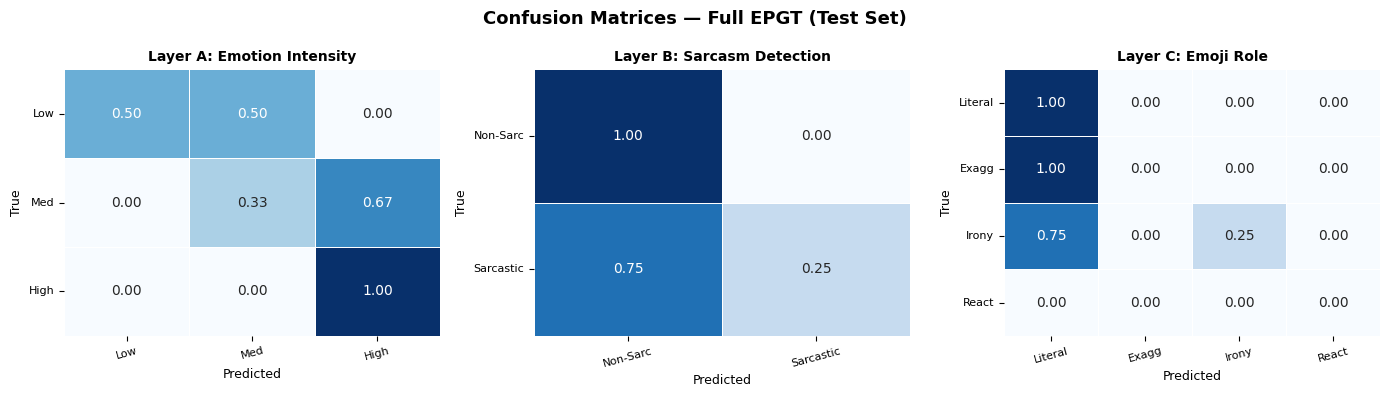

Saved: /content/drive/MyDrive/EPGT_Research/outputs/figures/confusion_matrices.png


In [10]:
# ============================================================
# CELL 5.3 — Confusion Matrices (Full EPGT)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if "epgt_full" in all_eval_results:
    cms = all_eval_results["epgt_full"]["confusion_matrices"]

    label_names = {
        "intensity": ["Low", "Med", "High"],
        "sarcasm"  : ["Non-Sarc", "Sarcastic"],
        "role"     : ["Literal", "Exagg", "Irony", "React"],
    }

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle("Confusion Matrices — Full EPGT (Test Set)",
                 fontsize=13, fontweight="bold")

    titles = {
        "intensity": "Layer A: Emotion Intensity",
        "sarcasm"  : "Layer B: Sarcasm Detection",
        "role"     : "Layer C: Emoji Role",
    }

    for ax, task in zip(axes, ["intensity", "sarcasm", "role"]):
        cm     = cms[task]
        labels = label_names[task]

        # Normalize per row (recall)
        cm_norm = cm.astype(float)
        row_sum = cm_norm.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1
        cm_norm = cm_norm / row_sum

        sns.heatmap(
            cm_norm,
            annot      = True,
            fmt        = ".2f",
            cmap       = "Blues",
            xticklabels= labels,
            yticklabels= labels,
            ax         = ax,
            linewidths = 0.5,
            vmin=0, vmax=1,
            cbar       = False,
        )
        ax.set_title(titles[task], fontsize=10, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=9)
        ax.set_ylabel("True",      fontsize=9)
        ax.tick_params(axis="x", rotation=15, labelsize=8)
        ax.tick_params(axis="y", rotation=0,  labelsize=8)

    plt.tight_layout()
    fig_path = DRIVE_ROOT / "outputs/figures/confusion_matrices.png"
    plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")

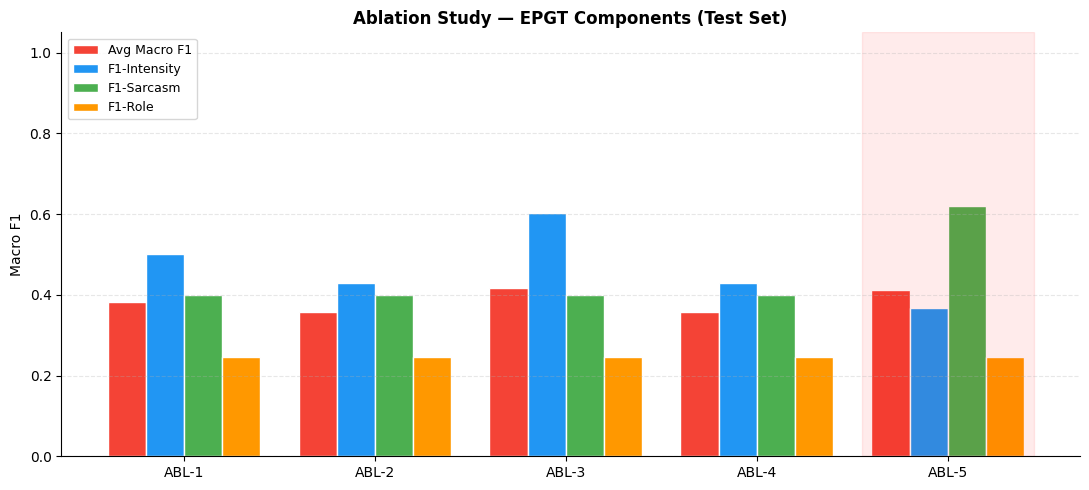

Saved: /content/drive/MyDrive/EPGT_Research/outputs/figures/ablation_bar.png


In [11]:
# ============================================================
# CELL 5.4 — Ablation Bar Chart
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

abl_labels  = []
abl_avg_f1  = []
abl_int_f1  = []
abl_sarc_f1 = []
abl_role_f1 = []

for run_name, res in ablation_results.items():
    m = res["test_metrics"]
    abl_labels.append(res["description"].split(":")[0])  # "ABL-1" dst
    abl_avg_f1.append(m["avg_macro_f1"])
    abl_int_f1.append(m["f1_macro_intensity"])
    abl_sarc_f1.append(m["f1_macro_sarcasm"])
    abl_role_f1.append(m["f1_macro_role"])

x          = np.arange(len(abl_labels))
bar_width  = 0.20
offsets    = [-1.5, -0.5, 0.5, 1.5]
metrics    = [abl_avg_f1, abl_int_f1, abl_sarc_f1, abl_role_f1]
met_labels = ["Avg Macro F1", "F1-Intensity", "F1-Sarcasm", "F1-Role"]
colors     = ["#F44336", "#2196F3", "#4CAF50", "#FF9800"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (vals, label, color, offset) in enumerate(
    zip(metrics, met_labels, colors, offsets)
):
    bars = ax.bar(
        x + offset * bar_width, vals,
        bar_width, label=label, color=color,
        edgecolor="white", linewidth=1,
    )

ax.set_title("Ablation Study — EPGT Components (Test Set)",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(abl_labels, fontsize=10)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

# Highlight ABL-5 (Full EPGT)
if len(abl_labels) >= 5:
    ax.axvspan(x[-1] - 0.45, x[-1] + 0.45, alpha=0.08,
               color="red", label="_nolegend_")

plt.tight_layout()
fig_path = DRIVE_ROOT / "outputs/figures/ablation_bar.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

In [12]:
# ============================================================
# CELL 5.5 — Error Analysis: Contoh Prediksi Salah
# ============================================================
# Tampilkan sampel di mana EPGT salah prediksi
# berguna untuk analisis kualitatif di paper.

import pandas as pd

if "epgt_full" in all_eval_results:
    pred_dict = all_eval_results["epgt_full"]["pred_dict"]

    df_test_raw = pd.read_csv(DRIVE_ROOT / "data/processed/test_processed.csv")

    INTENSITY_MAP = {0: "Low", 1: "Medium", 2: "High"}
    SARCASM_MAP   = {0: "Non-Sarcastic", 1: "Sarcastic"}
    ROLE_MAP      = {0: "Literal", 1: "Exaggeration", 2: "Irony", 3: "Reaction"}

    errors = []
    for i in range(len(df_test_raw)):
        row = df_test_raw.iloc[i]
        for task, label_map in [
            ("intensity", INTENSITY_MAP),
            ("sarcasm",   SARCASM_MAP),
            ("role",      ROLE_MAP),
        ]:
            pred  = pred_dict["preds"][task][i]
            label = pred_dict["labels"][task][i]
            if pred != label:
                errors.append({
                    "text"          : str(row.get("text", ""))[:80],
                    "emoji_sequence": str(row.get("emoji_sequence", "")),
                    "task"          : task,
                    "true_label"    : label_map.get(label, str(label)),
                    "pred_label"    : label_map.get(pred,  str(pred)),
                })

    df_errors = pd.DataFrame(errors)

    print("=" * 65)
    print("ERROR ANALYSIS — Full EPGT (Test Set)")
    print("=" * 65)
    print(f"Total errors : {len(df_errors)} / {len(df_test_raw) * 3} predictions")
    print(f"Error rate   : {len(df_errors) / (len(df_test_raw) * 3) * 100:.1f}%")

    print("\nErrors per task:")
    print(df_errors["task"].value_counts().to_string())

    print("\nSample error cases:")
    for _, row in df_errors.head(6).iterrows():
        print(f"\n  Task       : {row['task']}")
        print(f"  Text       : {row['text']}")
        print(f"  Emoji      : {row['emoji_sequence']}")
        print(f"  True label : {row['true_label']}")
        print(f"  Predicted  : {row['pred_label']}")

    # Simpan error analysis
    err_path = DRIVE_ROOT / "outputs/tables/error_analysis.csv"
    df_errors.to_csv(err_path, index=False)
    print(f"\nSaved: {err_path}")

ERROR ANALYSIS — Full EPGT (Test Set)
Total errors : 11 / 36 predictions
Error rate   : 30.6%

Errors per task:
task
role         4
intensity    4
sarcasm      3

Sample error cases:

  Task       : sarcasm
  Text       : plot twist terkejut 😲💀 ga nyangka
  Emoji      : 😲,💀
  True label : Sarcastic
  Predicted  : Non-Sarcastic

  Task       : role
  Text       : plot twist terkejut 😲💀 ga nyangka
  Emoji      : 😲,💀
  True label : Irony
  Predicted  : Literal

  Task       : sarcasm
  Text       : gilak beneran gak nyangka plot twistnya 💀 anjir
  Emoji      : 💀
  True label : Sarcastic
  Predicted  : Non-Sarcastic

  Task       : role
  Text       : gilak beneran gak nyangka plot twistnya 💀 anjir
  Emoji      : 💀
  True label : Irony
  Predicted  : Literal

  Task       : intensity
  Text       : beneran gak ketawa 💀 serius ini
  Emoji      : 💀
  True label : Medium
  Predicted  : High

  Task       : sarcasm
  Text       : beneran gak ketawa 💀 serius ini
  Emoji      : 💀
  True label : 

---
## BAGIAN 6 — NB06 COMPLETION REPORT

In [13]:
# ============================================================
# CELL 6.1 — NB06 Completion Report
# ============================================================

import json
from pathlib import Path

print("=" * 60)
print("NB06 COMPLETION REPORT")
print("EPGT Research — Evaluation & Ablation Study")
print("=" * 60)

print("\n[1] SOURCE FILES")
src_files = ["src/evaluation/evaluator.py"]
for f in src_files:
    p = DRIVE_ROOT / f
    print(f"  {'OK' if p.exists() else 'MISSING':>7}  {f}")

print("\n[2] TEST SET EVALUATION")
for run_name, res in all_eval_results.items():
    m = res["test_metrics"]
    print(
        f"  {run_name:<28}"
        f" avg_f1={m['avg_macro_f1']:.4f}"
        f" int={m['f1_macro_intensity']:.3f}"
        f" sarc={m['f1_macro_sarcasm']:.3f}"
        f" role={m['f1_macro_role']:.3f}"
    )

print("\n[3] ABLATION STUDY")
for run_name, res in ablation_results.items():
    m = res["test_metrics"]
    print(
        f"  {res['description']:<25}"
        f" avg_f1={m['avg_macro_f1']:.4f}"
    )

print("\n[4] OUTPUT FILES")
out_files = [
    "outputs/tables/evaluation_results.json",
    "outputs/tables/ablation_table.json",
    "outputs/tables/error_analysis.csv",
    "outputs/figures/confusion_matrices.png",
    "outputs/figures/ablation_bar.png",
]
for f in out_files:
    p = DRIVE_ROOT / f
    print(f"  {'OK' if p.exists() else 'MISSING':>7}  {f}")

print("\n[5] PIPELINE STATUS")
notebooks = [
    "NB01 — Data Collection       : DONE",
    "NB02 — Annotation & Split    : DONE",
    "NB03 — Preprocessing & Graph : DONE",
    "NB04 — Model Architecture    : DONE",
    "NB05 — Training Pipeline     : DONE",
    "NB06 — Evaluation & Ablation : DONE",
    "NB07 — Demo System           : NEXT",
]
for nb in notebooks:
    print(f"  {nb}")

print("\n[6] NEXT STEP")
print("  → NB07: Demo System Deployment")
print("    Interactive inference demo untuk satu teks input.")
print("    Output: prediksi 3 label + visualisasi graph + attention.")
print("\n" + "=" * 60)

NB06 COMPLETION REPORT
EPGT Research — Evaluation & Ablation Study

[1] SOURCE FILES
       OK  src/evaluation/evaluator.py

[2] TEST SET EVALUATION
  baseline_b1                  avg_f1=0.3642 int=0.447 sarc=0.400 role=0.246
  baseline_b3                  avg_f1=0.4192 int=0.612 sarc=0.400 role=0.246
  baseline_b2_intensity        avg_f1=0.3840 int=0.506 sarc=0.400 role=0.246
  baseline_b2_sarcasm          avg_f1=0.5040 int=0.342 sarc=0.778 role=0.393
  baseline_b2_role             avg_f1=0.2846 int=0.208 sarc=0.400 role=0.246
  epgt_full                    avg_f1=0.5416 int=0.611 sarc=0.621 role=0.393

[3] ABLATION STUDY
  ABL-1: No Graph           avg_f1=0.3822
  ABL-2: No Fusion          avg_f1=0.3581
  ABL-3: No Emoji           avg_f1=0.4157
  ABL-4: No Position        avg_f1=0.3581
  ABL-5: Full EPGT          avg_f1=0.4114

[4] OUTPUT FILES
       OK  outputs/tables/evaluation_results.json
       OK  outputs/tables/ablation_table.json
       OK  outputs/tables/error_analysis.csv
